# Macro Short-Vol Harvest — Findings

Can a **defined-risk** structure matched to a directional view harvest the macro VRP
at positive risk-adjusted P&L — and survive a drawdown? The single-name iron condor
could not (edge inside the bid/ask spread). This tests SPY/SPX/QQQ/IWM with three
structures and then stress-tests the winner over 20 years.

**Two tests**
1. **11-month per-name sweep** (`vrp_daily`): {iron condor, bull put spread,
   cash-secured put} × gate × short-delta × horizon, entry-spaced, honest holdout.
2. **Decisive 20-year drawdown** (`SPX + VIX`, 2006–2026; VIX/100 = SPX 30d IV) —
   does the edge survive 2008 / 2020 / 2022?

**Read with these caveats:** flat-vol credit ignores skew (conservative for the bull
put spread, *optimistic* for the condor's call side); VIX is 30d IV so **hold≈20d is
the clean read**; hold-to-expiry, no intra-trade management; P&L shown as
**return-on-risk (ROR)** = net ÷ capital-at-risk, so it is scale-invariant across the
20-year rise in index level.

In [1]:
import pathlib, sys
_here = pathlib.Path.cwd()
for _p in (_here, *_here.parents):
    if (_p / "pyproject.toml").exists():
        sys.path.insert(0, str(_p / "src")); break
import os
import matplotlib.pyplot as plt
import pandas as pd
import psycopg
from pydantic import SecretStr
from uw_scan.config import Settings
from uw_scan.reports.vrp_macro_harvest import run_vrp_macro_harvest
from uw_scan.reports.vrp_macro_drawdown import (
    load_spx_vix, run_spx_vix_drawdown, _backtest, STRESS_YEARS,
)
from uw_scan.reports.vrp_structure import CostModel
from uw_scan.storage.repository import Repository

dsn = (f"host={os.environ.get('UW_SCAN_DB_HOST','127.0.0.1')} "
       f"dbname={os.environ.get('UW_SCAN_DB_NAME','option_wizard_local')} "
       f"user={os.environ.get('UW_SCAN_DB_USER','chenxi')}")
conn = psycopg.connect(dsn)
repo = Repository(conn)
s = Settings(api_key=SecretStr("notebook"))

# run the 11-month sweep fresh (reproducible) and load it
sweep_meta = run_vrp_macro_harvest(repo=repo, settings=s)
sw = pd.DataFrame(repo.fetch_vrp_macro_sweep_results())
for c in ("win_rate","total_net","mean_net","mean_return_on_risk","breakeven_win_rate","breach_rate","short_delta","n_trades","median_net"):
    sw[c] = sw[c].astype(float)
print("sweep:", sweep_meta)

sweep: {'cells': 324, 'names': ['IWM', 'QQQ', 'SPX', 'SPY']}


## Part 1 — 11-month per-name sweep

Filtered to **credible samples (n ≥ 10 trades holdout)** — entry-spacing collapses
thin cells to noise, exactly as it did for single names. `edge` = win-rate minus the
break-even win-rate the structure needs (>0 = clears its small-win/big-loss hurdle).

=== structure comparison (holdout n>=10, medians) ===


,mean_return_on_risk,edge,total_net,n_trades
structure,,,,
bull_put_spread,0.057,0.065,445.389,17.0
cash_secured_put,0.002,0.171,1298.937,17.0
iron_condor,-0.037,-0.029,-109.130,17.0


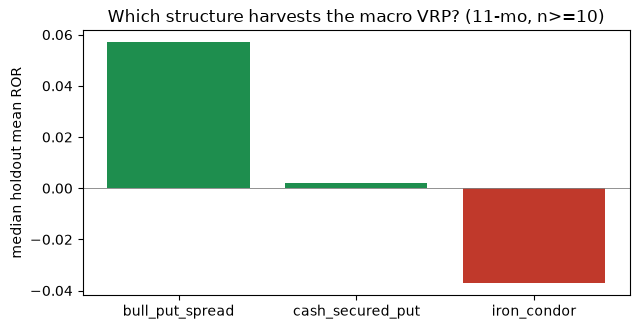

In [2]:
h = sw[(sw.scope == "holdout") & (sw.n_trades >= 10)].copy()
h["edge"] = h.win_rate - h.breakeven_win_rate

print("=== structure comparison (holdout n>=10, medians) ===")
sc = h.groupby("structure")[["mean_return_on_risk","edge","total_net","n_trades"]].median().round(3)
display(sc)

fig, ax = plt.subplots(figsize=(6.5,3.4))
colors = ["#1e8e4e" if v>0 else "#c0392b" for v in sc["mean_return_on_risk"]]
ax.bar(sc.index, sc["mean_return_on_risk"], color=colors)
ax.axhline(0, color="gray", lw=0.6); ax.set_ylabel("median holdout mean ROR")
ax.set_title("Which structure harvests the macro VRP? (11-mo, n>=10)")
plt.tight_layout(); plt.show()

In [3]:
print("=== per-name win-edge by structure (holdout n>=10) ===")
pivot = h.pivot_table(index="ticker", columns="structure", values="edge", aggfunc="mean")
display(pivot.round(3))

print("=== DELTA drill — bull put spread (holdout n>=10) ===")
bps = h[h.structure == "bull_put_spread"]
dd = bps.groupby("short_delta")[["mean_return_on_risk","edge","breach_rate","n_trades"]].mean().round(3)
display(dd)

=== per-name win-edge by structure (holdout n>=10) ===


structure,bull_put_spread,cash_secured_put,iron_condor
ticker,,,
IWM,0.087,0.213,-0.038
QQQ,0.051,0.157,NaN
SPX,-0.083,-0.014,NaN
SPY,0.520,0.770,NaN


=== DELTA drill — bull put spread (holdout n>=10) ===


,mean_return_on_risk,edge,breach_rate,n_trades
short_delta,,,,
0.16,0.029,0.233,0.094,15.4
0.25,0.036,0.097,0.231,15.4
0.30,0.031,0.046,0.269,15.4


## Part 2 — the decisive 20-year drawdown (SPX + VIX)

The 11-month window was a rising market, which flatters a short-downside structure.
Here every structure runs on 2006–2026 (incl. 2008, 2020, 2022). If the bull put
spread were just bull-market beta, the stress years would wreck it.

In [4]:
CONFIGS = [
    ("bull_put_spread", 0.16), ("bull_put_spread", 0.25), ("bull_put_spread", 0.30),
    ("cash_secured_put", 0.25), ("iron_condor", 0.16),
]
rows = []
for struct, delta in CONFIGS:
    r = run_spx_vix_drawdown(repo=repo, settings=s, structure=struct, short_delta=delta, hold_days=20)
    ov = r["overall"]
    rows.append(dict(
        structure=struct, short_delta=delta, n=ov["n_trades"], win=ov["win_rate"],
        mean_ror=ov["mean_return_on_risk"], total_ror=sum(y["total_ror"] for y in r["years"]),
        breach=ov["breach_rate"], breakeven=ov["breakeven_win_rate"],
        stress_ror=r["stress_total_ror"], calm_ror=r["calm_total_ror"], maxDD=r["max_drawdown_ror"],
    ))
dr = pd.DataFrame(rows)
fmt = {"win":"{:.0%}".format,"breach":"{:.0%}".format,"breakeven":"{:.0%}".format,
       "mean_ror":"{:+.3f}".format,"total_ror":"{:+.1f}".format,"stress_ror":"{:+.1f}".format,
       "calm_ror":"{:+.1f}".format,"maxDD":"{:+.1f}".format,"short_delta":"{:.2f}".format}
display(dr.style.format(fmt).hide(axis="index"))
print("span:", run_spx_vix_drawdown(repo=repo, settings=s, structure='bull_put_spread', short_delta=0.25, hold_days=20)["span"])

structure,short_delta,n,win,mean_ror,total_ror,breach,breakeven,stress_ror,calm_ror,maxDD
bull_put_spread,0.16,244,91%,+0.057,+14.0,10%,85%,+0.4,+13.6,-2.4
bull_put_spread,0.25,244,87%,+0.098,+24.0,16%,77%,+1.0,+22.9,-4.2
bull_put_spread,0.30,244,83%,+0.115,+28.1,20%,72%,+1.1,+27.0,-4.9
cash_secured_put,0.25,244,88%,+0.004,+0.9,16%,78%,+0.1,+0.8,-0.2
iron_condor,0.16,244,89%,+0.156,+38.0,14%,73%,+7.5,+30.5,-2.5


span: ('2006-01-03', '2026-05-21')


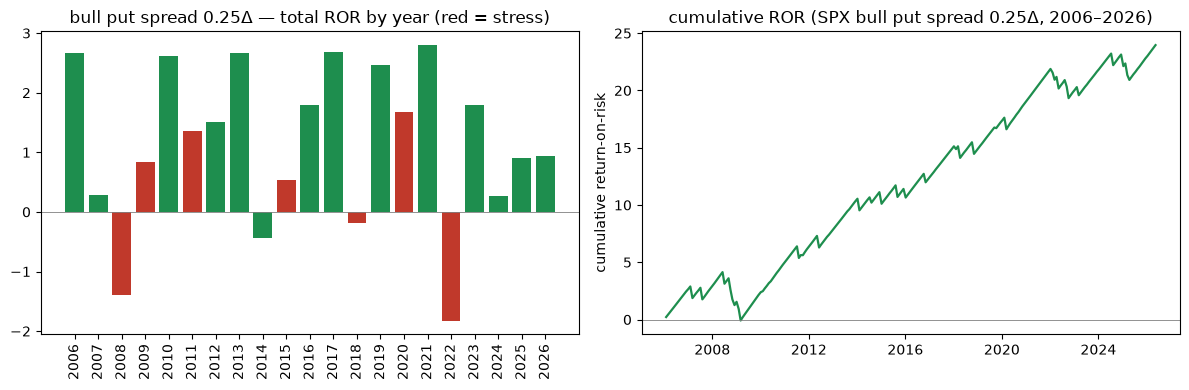

survives drawdowns: stress yrs net ROR +1.0, calm +22.9


In [5]:
# Headline config: bull put spread 0.25Δ — per-year P&L (stress years in red) + equity curve
cost = CostModel(s.vrp_cost_per_contract, s.vrp_slippage_frac, s.vrp_slippage_min, round_trip=s.vrp_cost_round_trip)
loaded = load_spx_vix(repo)
trades = _backtest(loaded, "SPX", kind="bull_put_spread", min_z=None,
                   short_delta=0.25, hold_days=20, r=s.vrp_risk_free_rate, cost=cost)
by_year = {}
for t in trades:
    by_year.setdefault(t.entry_date.year, []).append(t.return_on_risk)
yrs = sorted(by_year); tot = [sum(by_year[y]) for y in yrs]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar([str(y) for y in yrs], tot,
       color=["#c0392b" if y in STRESS_YEARS else "#1e8e4e" for y in yrs])
a1.axhline(0, color="gray", lw=0.6); a1.set_title("bull put spread 0.25Δ — total ROR by year (red = stress)")
a1.tick_params(axis="x", rotation=90)

cum, curve, dates = 0.0, [], []
for t in sorted(trades, key=lambda x: x.expiry_date):
    cum += t.return_on_risk; curve.append(cum); dates.append(t.expiry_date)
a2.plot(pd.to_datetime(dates), curve, color="#1e8e4e", lw=1.6)
a2.axhline(0, color="gray", lw=0.6)
a2.set_title("cumulative ROR (SPX bull put spread 0.25Δ, 2006–2026)")
a2.set_ylabel("cumulative return-on-risk")
plt.tight_layout(); plt.show()
print(f"survives drawdowns: stress yrs net ROR {sum(t for y,t in zip(yrs,tot) if y in STRESS_YEARS):+.1f}, "
      f"calm {sum(t for y,t in zip(yrs,tot) if y not in STRESS_YEARS):+.1f}")

## Conclusions

(Numbers reproduced live from the run; full write-up in
[`macro-short-vol-verdict.md`](./macro-short-vol-verdict.md).)

- **The edge survives the drawdown.** The bull put spread is positive over 20 years,
  clears its break-even win-rate, and the defined-risk wing caps the tail — it goes
  ≈flat in stress years rather than blowing up. This is the first drawdown-robust
  edge in the whole VRP investigation.
- **The iron condor *looks* best over a full cycle** (call side hedges selloffs) **but
  rides on a flat-vol over-pricing of index call credit** — real call IV < ATM. So
  the bull put spread is the cleanly-conservative winner (real put skew makes it
  *better*), and the condor needs real-fill confirmation.
- **Cash-secured put is out** — high win-rate, ROR ≈ 0 (ties up strike capital for
  nothing).
- **Delta:** 0.25Δ short / 0.125Δ wing is the balanced default; 0.16Δ conservative,
  0.30Δ aggressive.
- **IWM** belongs in the bullish put-spread bucket (positive), not the condor.

**Entry/exit:** systematic always-on, one position at a time, 20-DTE, sold at the
close; hold to expiry (the wing is the stop). Management (close winners at ~50% of
max credit) is the next, untested refinement and needs daily real-fill marks.

**Remaining gap to "traded":** real-fill NBBO (forward-only recorder) and QQQ/IWM
long-history. The model is conservative for the bull put spread, so real fills should
help, not hurt.